## _Neural Data Science Project SoSe2026_ - Parameter inference with Jaxley

**Lecturer**: Prof. Dr. Philipp Berens, Dr. Jan Lause

**Tutors**: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

**Student names**: <span >*Lucía Grande González, Andre Potthoff, Niclas Collmer* </span>

**LLM Disclaimer**: <span>*AI was used in making this [ADD DETAILS] !!!!!!!* </span>

## Context

The pyloric network of the stomatogastric ganglion (STG) is a well-studied component of the crustacean nervous system that provides valuable insights into neural circuit function. Computational models of the pyloric network have been instrumental in understanding how neural circuits maintain functional stability despite biological variability and perturbations. It consists of about 14 neurons that generate a rhythmic motor pattern controlling the pylorus of the crustacean stomach that are connected by a set of Cholinergic and Glutamatergic synapses.

The key neuron types include:
- Anterior Burster (AB) neuron
- Pyloric Dilator (PD) neurons
- Lateral Pyloric (LP) neuron
- Pyloric (PY) neurons

For more context you can read the following papers:
- [Similar network activity from disparate circuit parameters](https://www.nature.com/articles/nn1352)
- [Alternative to hand-tuning conductance-based models](https://journals.physiology.org/doi/full/10.1152/jn.00641.2003)
- [Training deep neural density estimators to identify mechanistic models of neural dynamics](https://elifesciences.org/articles/56261)

In this project you will fit a simplified model of the STG circuit, which approximates all neurons of the same type with a single compartmental model and also treats the electrically coupled AB and PD neurons as a single neuron. This leads to the following circuit:

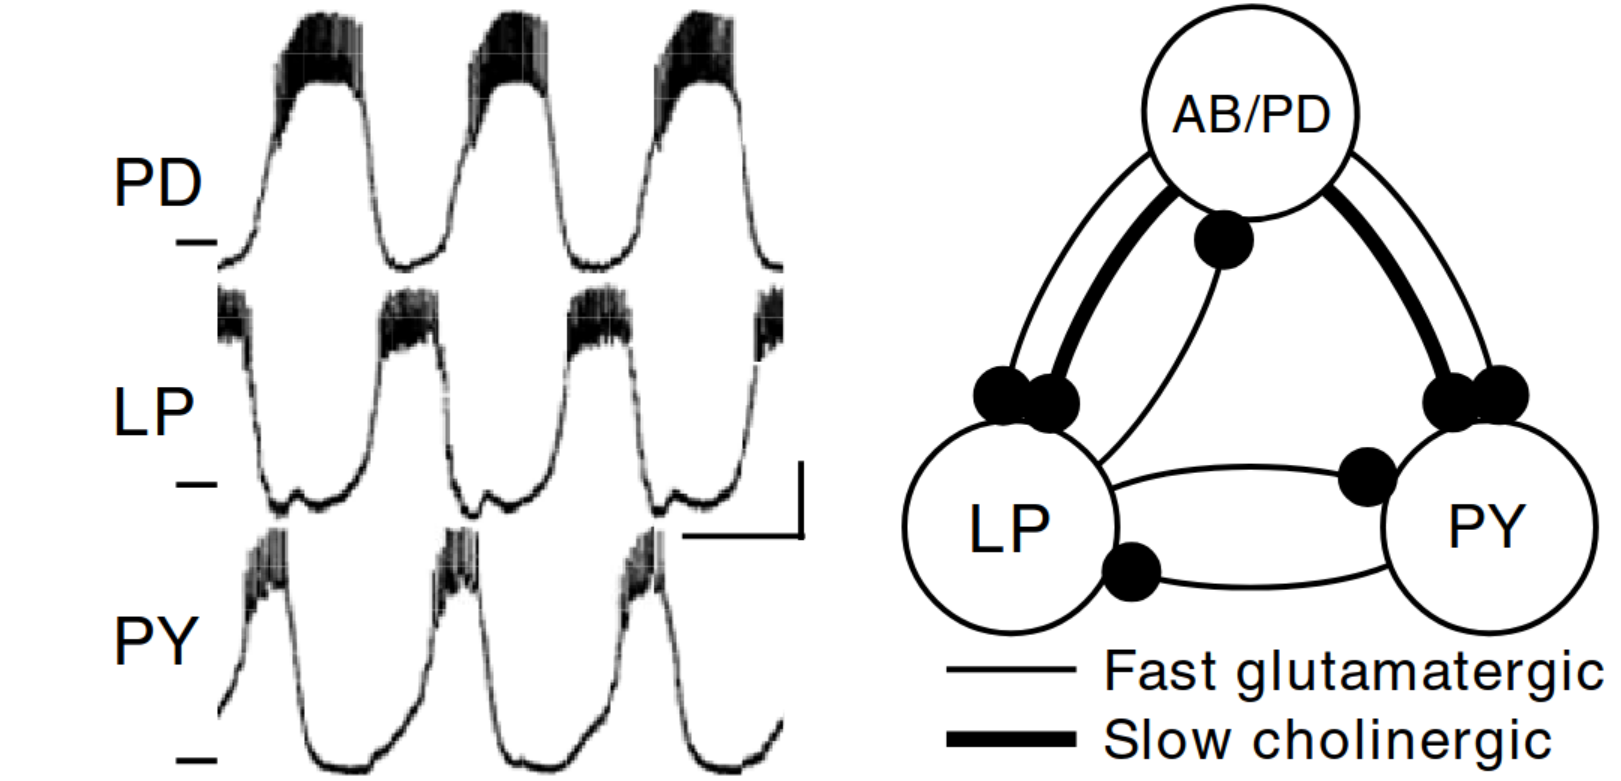

## The Model

You can find an implementation of the STG model in `Jaxley` at [jaxley-models](https://github.com/jaxleyverse/jaxley-models). For details on how to work with `Jaxley` see [Jaxley Docs](https://jaxley.readthedocs.io/en/latest/). We recommend to familiarize yourself with the toolbox and the model first. Specifcally, check out the [tutorials](https://jaxley.readthedocs.io/en/latest/tutorials.html) and read the code in `pyloric/channels.py`, `pyloric/synapses.py` and `pyloric/model.py` to gain an understanding of how the model is implemented. You should pay particular attention to `PyloricNetwork`. In addition you can use `.nodes` and `.edges` to inspect the neurons and synapses respectively.

## Data

The data comes from a noisy simulation of the STG circuit with unknown parameters.

In [1]:
# configure jax to use 64bit precision and cpu
from jax import config

config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")

import os
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".8"

In [ ]:
#basics
import numpy as np
import matplotlib.pyplot as plt
import jupyter_black
from numpy import ndarray
from typing import Union, Optional, Tuple

# from torch import Tensor # crashed my kernel for some reason so I commented it out for now

#new libraries
from jaxley_models import PyloricNetwork
import jax.numpy as jnp
import jaxley as jx
import jax

from utils import * # import all functions from utils.py

jupyter_black.load() # for cell formatting in jupyter notebooks


## Explore the data

In [3]:
# import and plot the data

t_obs, *v_obs = np.loadtxt("../data/pyloric_observation.csv", unpack=True)
fig, axs = plot_pyloric(t_obs, v_obs)
plt.show()

NameError: name 'plot_pyloric' is not defined

## Question
**What synaptic conductances gave rise to the recorded trace above and are there more than one viable set of conductances?**

Implement all steps of the processing pipeline that are necessary to answer them. Think of: 
1. Pre-processing
2. Efficient simulator usage
3. Suitable summary statistics / loss functions
4. A suitable inference algorithm (Simulation-based inference, gradient-descent, ...)
5. Verification of your results

We will restrict ourselves to fitting only the synapses of this circuit. The remaining parameters are kept at their defaults. Suitable bounds for the synaptic conductances are $(1e^{-5}, 10)~ \mu S$. It is sufficient to assess the soundness of your parameter estimate qualitatively. Additional insights and analyses (such as a quantitative assesment) will be positively factored into the overall grade.

### Note
- To complete the project succesfully you should have experience with autograd libraries. In particular [jax](https://docs.jax.dev/en/latest/index.html) and/or [pytorch](https://docs.jax.dev/en/latest/index.html).
- We recommend starting with the tutorials on [jaxley](https://jaxley.readthedocs.io/en/latest/tutorials.html) and/or [sbi](https://sbi-dev.github.io/sbi/latest/tutorials/) to familiarize yourself with the software first.
- To get a better understanding of the algorithms make sure to read
    - [Differentiable simulation enables large-scale training of detailed biophysical models of neural dynamics](https://www.biorxiv.org/content/10.1101/2024.08.21.608979v1) (Jaxley Paper)
    - [Flexible statistical inference for mechanistic models of neural dynamics](https://arxiv.org/abs/1711.01861) (SNPE-B Paper) / [Automatic Posterior Transformation for Likelihood-free Inference](https://proceedings.mlr.press/v97/greenberg19a/greenberg19a.pdf) (SNPE-C Paper)
- We recommend running your simulations at `dt=0.025` and using 64 bit floating point precision.

**Be careful**, the observation is very long (4s), this makes the simuluator quite expensive to run for many simulations. While developing your code, think about how you can get a way with running it less often or more cheaply.